# Programmstruktur
1. Wärmeleistung der Anlage <br>
1.1. Spitzenbelastung als Auslegungswert (GW-Entzugsleistung und Förderrate) <br>
1.2. Monatsprofil <br><br>
2. Hydrogeologische Berechnungen <br>
2.1. Hydrogeologische Eingangsparameter <br>
2.2. Fassungsvermögen Qf  <br>
2.3. Wasserandrang Qa <br>
2.4. Optimale Brunnenleistung Qopt <br><br>
3. Brunnendimensionierung <br>
3.1. Hydraulisches Abstandskriterium <br>
3.2. Thermisches Abstandskriterium <br>
3.3. Thermische Ausbreitung <br><br>
4. Finale Auswertung

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display
import ipywidgets as widgets
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import sympy as sp
import math

# 1. Wärmeleistung der Anlage

## 1.1. Spitzenbelastung als Auslegungswert

In [2]:
# Klimagraph für Städte/Regionen in Deutschland
url = "https://www.klimadiagramme.de/Deutschland/aachen2.html" # Hier kann die URL für die gewünschte Stadt/Region angepasst werden
tables = pd.read_html(url) 

climatediag_df = tables[1]
climatediag_df = climatediag_df.iloc[5:].reset_index(drop=True)
climatediag_df.columns = ['Monat', 'Niederschlag [mm]', 'Temperatur [°C]']
climatediag_df = climatediag_df.astype({"Temperatur [°C]": float, "Niederschlag [mm]": float})

In [3]:
clim_df_plot = climatediag_df[climatediag_df["Monat"] != "Jahr"]
clim_x = clim_df_plot["Monat"]
clim_y1 = clim_df_plot["Temperatur [°C]"]
clim_y2 = clim_df_plot["Niederschlag [mm]"]

fig, ax1 = plt.subplots(figsize=(6,4))
Ort = "Aachen"
plt.title("Klimagraph für " + Ort)

# Linke y-Achse für Niederschlag
ax1.plot(clim_x, clim_y2, color='blue', linewidth=1, label="Niederschlag (mm)")
ax1.fill_between(clim_x, clim_y2, color='blue', alpha=0.2)
ax1.bar(clim_x, clim_y2, alpha=0.3, color='blue', width=0.1)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_ylabel("Niederschlag (mm)", color='blue')
ax1.set_xlabel("Monat")
ax1.set_xticks(clim_x)
ax1.set_xlim([0, 11])

# Rechte y-Achse für Temperatur
ax2 = ax1.twinx()
ax2.plot(clim_x, clim_y1, linewidth=2, color='red', label="Temperatur (°C)")
ax2.set_ylabel('Temperatur (°C)', color='red')  

# Anpassung der y-Achsen, damit 0 auf beiden Achsen übereinstimmt
y1_min = -10
y1_max = clim_df_plot["Niederschlag [mm]"].max() + 10
ax1.set_ylim(y1_min, y1_max)
zero_pos = (0 - y1_min) / (y1_max - y1_min)
temp_max = clim_df_plot["Temperatur [°C]"].max() + 5
temp_min = -zero_pos / (1 - zero_pos) * temp_max
ax2.set_ylim(temp_min, temp_max)


fig.tight_layout()
fig.legend(bbox_to_anchor=(0.57, 0.92), loc='upper left')
plt.close(fig)

out_plot = widgets.Output()
with out_plot:
    display(fig)

out_df = widgets.Output()
with out_df:
    display(climatediag_df)

display(widgets.HBox([out_df, out_plot])) # Anzeige von DataFrame und Klimagraph nebeneinander

In [4]:
# Dropdown-Menu zur Auswahl des Gebäudetyps
dropdown = widgets.Dropdown(
    options=['Einfamilienhaus', 'Mehrfamilienhaus', 'Schule'],
    value='Einfamilienhaus', # Standardwert
    description='Wähle Gebäudetyp:',
    disabled=False,
    layout=widgets.Layout(width='300px'),
    style={'description_width': '150px'}
)
display(dropdown)

# Zugriff auf den Wert
def on_value_change(change):
    print(f"Ausgewählt: {change.new}")
dropdown.observe(on_value_change, names='value')

Dropdown(description='Wähle Gebäudetyp:', layout=Layout(width='300px'), options=('Einfamilienhaus', 'Mehrfamil…

In [5]:
# Spezifische Heizlast basierend auf Baujahr und Dämmstandard der Gebäudes -> Tabelle dient zur Orientierung
Geb_richtwerte_heiz = pd.DataFrame({
    "Baujahr": ["Altbau (vor 1977)", "Sanierter Altbau (1978-1995)", "Neubau (ab 2002)"],
    "Spezifische Heizlast [W/m²]": ["120 - 95", "95 - 70", "50 - 25"], # Gilt für Normaußenbedingungen
    "Heizgrenztemperatur [°C]": ["15 - 17", "14 - 16", "12 - 15"]
})
Geb_richtwerte_kühl = pd.DataFrame({
    "Gebäudetyp": ["Wohngebäude", "Schule"],
    "Spezifische Kühllast [W/m²]": ["30 - 45", "40 - 55"], # Kühlgrenztemperatur schwer zu beurteilen, tendenziell Kühlung von Juni-September
})
display(Geb_richtwerte_heiz)
display(Geb_richtwerte_kühl)

,Baujahr,Spezifische Heizlast [W/m²],Heizgrenztemperatur [°C]
0,Altbau (vor 1977),120 - 95,15 - 17
1,Sanierter Altbau (1978-1995),95 - 70,14 - 16
2,Neubau (ab 2002),50 - 25,12 - 15


,Gebäudetyp,Spezifische Kühllast [W/m²]
0,Wohngebäude,30 - 45
1,Schule,40 - 55


In [6]:
# Angabe der Gebäudefläche
Gebäudefläche = 160 # in m² -> für MFH Anzahl Wohnungen * Wohnungsfläche

# Angabe der spezifischen Heiz- und Kühllast (kann aus Tabellen entnommen oder individuell geschätzt werden)
spez_heizlast = 50 # W/m²
spez_kühllast = 40 # W/m²

# Angabe der COPs für Heiz- und Kühlbetrieb der Wärmepumpe
COP_h = 4.5
COP_k = 3.5

In [7]:
# Berechnung der maximalen Heiz-, Kühlleistung
P_h_max = Gebäudefläche * spez_heizlast # W
P_k_max = Gebäudefläche * spez_kühllast # W
print(f"Maximale Heizleistung: {P_h_max} W")
print(f"Maximale Kühlleistung: {P_k_max} W")

Maximale Heizleistung: 8000 W
Maximale Kühlleistung: 6400 W


In [8]:
# Umrechnung der Heizleistung zu GW-Entzugsleistung
P_gw_h_max = P_h_max * (1-(1/COP_h))
P_gw_k_max = P_k_max * (1-(1/COP_k))
print(f"Maximale GW-Entzugsleistung für Heizung: {round(P_gw_h_max, 2)} W")
print(f"Maximale GW-Entzugsleistung für Kühlung: {round(P_gw_k_max, 2)} W")


Maximale GW-Entzugsleistung für Heizung: 6222.22 W
Maximale GW-Entzugsleistung für Kühlung: 4571.43 W


In [9]:
# Lokale Grundwassertemperatur ~ Lokale durchschnittliche Lufttemperatur
GW_temp = climatediag_df['Temperatur [°C]'][:12].mean()
print('Die lokale Grundwassertemperatur beträgt ca.', round(GW_temp,2), '°C')
if GW_temp-6<5:
    temp_min = 5
else:
    temp_min = GW_temp - 6
if GW_temp + 6 > 20:
    temp_max = 20
else:
    temp_max = GW_temp + 6

print('Die Temperaturspreizung ∆T des Grundwassers darf maximal 6 K betragen, die minimale Einleittemperatur liegt bei 5 °C und die maximale bei 20 °C (bei Kühlbetrieb) (LANUV-Arbeitsblatt 39).')
print('Somit darf das eingeleitete GW den Bereich von', round(temp_min,2), '°C bis', round(temp_max,2), '°C nicht überschreiten.')

Die lokale Grundwassertemperatur beträgt ca. 10.06 °C
Die Temperaturspreizung ∆T des Grundwassers darf maximal 6 K betragen, die minimale Einleittemperatur liegt bei 5 °C und die maximale bei 20 °C (bei Kühlbetrieb) (LANUV-Arbeitsblatt 39).
Somit darf das eingeleitete GW den Bereich von 5 °C bis 16.06 °C nicht überschreiten.


In [10]:
# Angabe der Temperaturdifferenz ΔT [K]
T_slider = widgets.IntSlider(
    value=3,
    min=0,
    max=6,
    step=1,
    description='Temperaturdifferenz ΔT [K]:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='460px'),
    style={'description_width': '210px'}
)
display(T_slider)

IntSlider(value=3, continuous_update=False, description='Temperaturdifferenz ΔT [K]:', layout=Layout(width='46…

In [11]:
def calc_Q_vol(P_gw, delta_T):
    """Berechnung des benötigten Fördervolumenstroms in m³/h.
    Args:
        P_gw (float): Entzugsleistung des Grundwassers in W
        delta_T (float): Temperaturdifferenz in K"""
    rho = 1000  # Dichte in kg/m³
    c = 4180  # Spezifische Wärmekapazität in J/kgK
    Q_vol = (P_gw) / (rho * c * delta_T) #W/(J/m3)--> m3/s
    Q_vol_m3h = Q_vol * 3600  # Umrechnung von m³/s auf m³/h
    Q_vol_Ls = Q_vol * 1000 # Umrechnung von m³/s auf L/s
    return round(Q_vol, 5), round(Q_vol_m3h, 5), round(Q_vol_Ls, 5)

# Variante nur mit Ausgabe des Fördervolumenstroms in m³/h
# def calc_Q_vol_m3h(P_gw, delta_T):
#     """Berechnung des benötigten Fördervolumenstroms in m³/h.
#     Args:
#         P_gw (float): Entzugsleistung des Grundwassers in W
#         delta_T (float): Temperaturdifferenz in K"""
#     rho = 1000  # Dichte in kg/m³
#     c = 4180  # Spezifische Wärmekapazität in J/kgK
#     Q_vol = (P_gw) / (rho * c * delta_T) #W/(J/m3)--> m3/s
#     Q_vol_m3h = Q_vol * 3600  # Umrechnung von m³/s auf m³/h
#     return round(Q_vol_m3h, 5)

In [12]:
Q_vol_h_value = calc_Q_vol(P_gw_h_max, T_slider.value)
Q_vol_k_value = calc_Q_vol(P_gw_k_max, T_slider.value)
print("GW-Förderrate für Heizbetrieb:\n"
    f"  {Q_vol_h_value[0]} m³/s\n"
    f"  {Q_vol_h_value[1]} m³/h\n"
    f"  {Q_vol_h_value[2]} L/s")
print("GW-Förderrate für Kühlbetrieb:\n"
    f"  {Q_vol_k_value[0]} m³/s\n"
    f"  {Q_vol_k_value[1]} m³/h\n"
    f"  {Q_vol_k_value[2]} L/s")

GW-Förderrate für Heizbetrieb:
  0.0005 m³/s
  1.78628 m³/h
  0.49619 L/s
GW-Förderrate für Kühlbetrieb:
  0.00036 m³/s
  1.31237 m³/h
  0.36455 L/s


In [13]:
print("Das maximal erforderliche GW-Fördervolumen beträgt:", round(max(Q_vol_h_value[1], Q_vol_k_value[1]), 2), "m³/h")

Das maximal erforderliche GW-Fördervolumen beträgt: 1.79 m³/h


## 1.2. Monatliche Verteilung (Wärmebedarf, Heizleistung, Gw-Entzugsleistung)

In [14]:
# 1. Teil: Heiz- und Kühlgradtage berechnen
h_grenztemp = 14
k_grenztemp = 17
tage = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
s=tage.sum()
heiz_df_0 = climatediag_df.copy()
heiz_df_0 = heiz_df_0.drop('Niederschlag [mm]', axis=1)
heiz_df_0['Anzahl Tage'] = ([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31, s])

heiz_df = heiz_df_0.iloc[:, [0, 2, 1]].copy()  # reorder columns
heiz_df['Heizgradtage'] = np.maximum(0, h_grenztemp - heiz_df['Temperatur [°C]']) * heiz_df['Anzahl Tage'] #np.max verhindert negative Werte
heiz_df['Kühlgradtage'] = np.maximum(0, heiz_df['Temperatur [°C]'] - k_grenztemp) * heiz_df['Anzahl Tage'] #np.max verhindert negative Werte
sum_HGT = heiz_df['Heizgradtage'][:12].sum()
sum_KGT = heiz_df['Kühlgradtage'][:12].sum()
heiz_df.loc[12, 'Heizgradtage'] = sum_HGT
heiz_df.loc[12, 'Kühlgradtage'] = sum_KGT   
heiz_df


,Monat,Anzahl Tage,Temperatur [°C],Heizgradtage,Kühlgradtage
0,Jan,31,3.0,341.0,0.0
1,Feb,28,3.2,302.4,0.0
2,Mar,31,6.1,244.9,0.0
3,Apr,30,8.7,159.0,0.0
4,Mai,31,13.2,24.8,0.0
5,Jun,30,15.7,0.0,0.0
6,Jul,31,17.9,0.0,27.9
7,Aug,31,17.7,0.0,21.7
8,Sep,30,14.4,0.0,0.0
9,Okt,31,10.5,108.5,0.0


In [15]:
# Berechnung der Betriebsstunden pro Monat
jahresbetriebsstunden_h = 2000
jahresbetriebsstunden_k = 300
heiz_df['Betriebsstunden Heiz'] = round((heiz_df['Heizgradtage'] / heiz_df['Heizgradtage'][12]) * jahresbetriebsstunden_h, 1)
heiz_df['Betriebsstunden Kühl'] = round((heiz_df['Kühlgradtage'] / heiz_df['Kühlgradtage'][12]) * jahresbetriebsstunden_k, 1)
# heiz_df['Betriebsstunden Heiz pro Tag'] = round(heiz_df['Betriebsstunden Heiz'] / heiz_df['Anzahl Tage'], 1)
heiz_df

,Monat,Anzahl Tage,Temperatur [°C],Heizgradtage,Kühlgradtage,Betriebsstunden Heiz,Betriebsstunden Kühl
0,Jan,31,3.0,341.0,0.0,396.2,0.0
1,Feb,28,3.2,302.4,0.0,351.3,0.0
2,Mar,31,6.1,244.9,0.0,284.5,0.0
3,Apr,30,8.7,159.0,0.0,184.7,0.0
4,Mai,31,13.2,24.8,0.0,28.8,0.0
5,Jun,30,15.7,0.0,0.0,0.0,0.0
6,Jul,31,17.9,0.0,27.9,0.0,168.7
7,Aug,31,17.7,0.0,21.7,0.0,131.3
8,Sep,30,14.4,0.0,0.0,0.0,0.0
9,Okt,31,10.5,108.5,0.0,126.1,0.0


In [16]:
# Warmwasserbedarf pro Monat
personen = 4
WW_bedarf = 600 #in kWh pro Person und Jahr (Durchschnittswert)
P_wp_ww = 5 # Leistung Wärmepumpe für Warmwasserbereitung in kW

heiz_df['Betriebsstunden WW'] = round((personen * WW_bedarf) / (P_wp_ww * 12), 1) #monatlicher WW-Betriebsstunden in h (konstant)
heiz_df.loc[12, 'Betriebsstunden WW'] = heiz_df['Betriebsstunden WW'][:12].sum()
heiz_df 

,Monat,Anzahl Tage,Temperatur [°C],Heizgradtage,Kühlgradtage,Betriebsstunden Heiz,Betriebsstunden Kühl,Betriebsstunden WW
0,Jan,31,3.0,341.0,0.0,396.2,0.0,40.0
1,Feb,28,3.2,302.4,0.0,351.3,0.0,40.0
2,Mar,31,6.1,244.9,0.0,284.5,0.0,40.0
3,Apr,30,8.7,159.0,0.0,184.7,0.0,40.0
4,Mai,31,13.2,24.8,0.0,28.8,0.0,40.0
5,Jun,30,15.7,0.0,0.0,0.0,0.0,40.0
6,Jul,31,17.9,0.0,27.9,0.0,168.7,40.0
7,Aug,31,17.7,0.0,21.7,0.0,131.3,40.0
8,Sep,30,14.4,0.0,0.0,0.0,0.0,40.0
9,Okt,31,10.5,108.5,0.0,126.1,0.0,40.0


In [17]:
# Angabe des Jahreswärmebedarfs [kWh/a] nach Gebäudetyp
if dropdown.value == 'Einfamilienhaus':
    Jahreswärmebedarf_default = 15000
elif dropdown.value == 'Mehrfamilienhaus':
    Jahreswärmebedarf_default = 50000
else:  # Schule
    Jahreswärmebedarf_default = 150000

Jahreswärmebedarf_slider = widgets.IntSlider(
    value=Jahreswärmebedarf_default,
    min=0,
    max=200000,
    step=100,
    description='Jahreswärmebedarf [kWh/a]:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='520px'),
    style={'description_width': '210px'}
)

Jahreskühlbedarf_slider = widgets.IntSlider( #maybe auch abhängig vom Gebäudetyp defaults einrichten
    value=600,
    min=0,
    max=5000,
    step=100,
    description='Jahreskühlbedarf [kWh/a]:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d',
    layout=widgets.Layout(width='520px'),
    style={'description_width': '210px'}
)
display(Jahreswärmebedarf_slider)
display(Jahreskühlbedarf_slider)

IntSlider(value=15000, continuous_update=False, description='Jahreswärmebedarf [kWh/a]:', layout=Layout(width=…

IntSlider(value=600, continuous_update=False, description='Jahreskühlbedarf [kWh/a]:', layout=Layout(width='52…

In [18]:
# Monatliche Verteilung des Wärme-, Kühl- und WW-Bedarfs
WB_df = pd.DataFrame(index=range(12), columns=['Monat', 'Wärmebedarf [kWh]', 'Kühlbedarf [kWh]', 'WW-Bedarf [kWh]'])

In [19]:
WB_df['Monat'] = heiz_df['Monat'][:12].values
WB_df['Wärmebedarf [kWh]'] = [Jahreswärmebedarf_slider.value * (heiz_df['Heizgradtage'][i]/heiz_df['Heizgradtage'][12]) for i in range(12)]
WB_df['Kühlbedarf [kWh]'] = [Jahreskühlbedarf_slider.value * (heiz_df['Kühlgradtage'][i]/heiz_df['Kühlgradtage'][12] * (-1)) for i in range(12)]
WB_df['WW-Bedarf [kWh]'] = [(personen * WW_bedarf) / 12 for i in range(12)]
WB_df = WB_df.round(1)
display(WB_df)

,Monat,Wärmebedarf [kWh],Kühlbedarf [kWh],WW-Bedarf [kWh]
0,Jan,2971.2,-0.0,200.0
1,Feb,2634.9,-0.0,200.0
2,Mar,2133.9,-0.0,200.0
3,Apr,1385.4,-0.0,200.0
4,Mai,216.1,-0.0,200.0
5,Jun,0.0,-0.0,200.0
6,Jul,0.0,-337.5,200.0
7,Aug,0.0,-262.5,200.0
8,Sep,0.0,-0.0,200.0
9,Okt,945.4,-0.0,200.0


In [20]:
# Monatliche Verteilung der Heiz-, Kühl- und WW-Leistung und Umrechnung zur Gesamt-GW-Entzugsleistung
P_cols=['Monat', 'Heizleistung [W]','Kühlleistung [W]', 'Heizleistung WW [W]', 'COP Heizen','COP Kühlen','COP WW', 'GW-Entzugsleistung Heizen [W]', 'GW-Entzugsleistung Kühlen [W]', 'GW-Entzugsleistung WW [W]']
P_df = pd.DataFrame(index=range(12), columns=P_cols)

In [21]:
# Monatliche Verteilung des Wärmebedarfs [kWh/Monat]
P_df['Monat'] = heiz_df['Monat'][:12].values
P_df['Heizleistung [W]'] = [(WB_df['Wärmebedarf [kWh]'][i]*1000) / (heiz_df['Anzahl Tage'][i]*24) for i in range(12)]
P_df['Kühlleistung [W]'] = [(WB_df['Kühlbedarf [kWh]'][i]*1000) / (heiz_df['Anzahl Tage'][i]*24) for i in range(12)]
P_df['Heizleistung WW [W]'] = [(WB_df['WW-Bedarf [kWh]'][i]*1000) / (heiz_df['Anzahl Tage'][i]*24) for i in range(12)]
P_df['COP Heizen'] = [4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]
P_df['COP Kühlen'] = [3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5]
P_df['COP WW'] = [3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5, 3.5]
P_df['GW-Entzugsleistung Heizen [W]'] = [P_df['Heizleistung [W]'][i] * ((P_df['COP Heizen'][i]-1)/P_df['COP Heizen'][i]) for i in range(12)] 
P_df['GW-Entzugsleistung Kühlen [W]'] = [P_df['Kühlleistung [W]'][i] * ((P_df['COP Kühlen'][i]-1)/P_df['COP Kühlen'][i]) for i in range(12)]
P_df['GW-Entzugsleistung WW [W]'] = [P_df['Heizleistung WW [W]'][i] * ((P_df['COP WW'][i]-1)/P_df['COP WW'][i]) for i in range(12)] 
P_df = P_df.round(2)
P_df

,Monat,Heizleistung [W],Kühlleistung [W],Heizleistung WW [W],COP Heizen,COP Kühlen,COP WW,GW-Entzugsleistung Heizen [W],GW-Entzugsleistung Kühlen [W],GW-Entzugsleistung WW [W]
0,Jan,3993.55,-0.00,268.82,4.0,3.5,3.5,2995.16,-0.00,192.01
1,Feb,3920.98,-0.00,297.62,4.0,3.5,3.5,2940.74,-0.00,212.59
2,Mar,2868.15,-0.00,268.82,4.0,3.5,3.5,2151.11,-0.00,192.01
3,Apr,1924.17,-0.00,277.78,4.0,3.5,3.5,1443.12,-0.00,198.41
4,Mai,290.46,-0.00,268.82,4.0,3.5,3.5,217.84,-0.00,192.01
5,Jun,0.00,-0.00,277.78,4.0,3.5,3.5,0.00,-0.00,198.41
6,Jul,0.00,-453.63,268.82,4.0,3.5,3.5,0.00,-324.02,192.01
7,Aug,0.00,-352.82,268.82,4.0,3.5,3.5,0.00,-252.02,192.01
8,Sep,0.00,-0.00,277.78,4.0,3.5,3.5,0.00,-0.00,198.41
9,Okt,1270.70,-0.00,268.82,4.0,3.5,3.5,953.02,-0.00,192.01


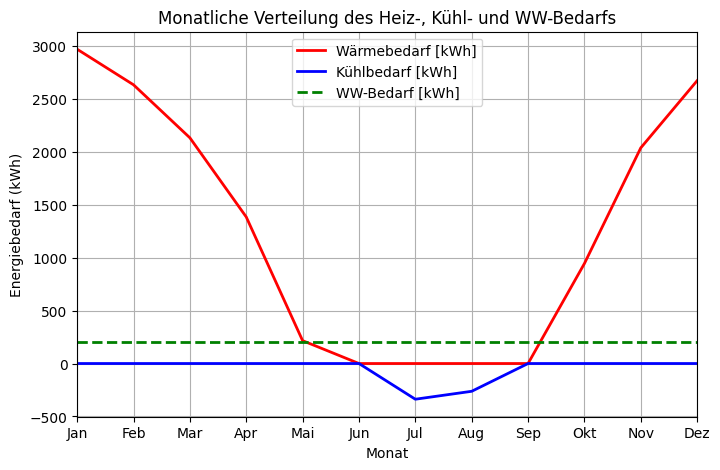

Der Jahreswärmebedarf beträgt: 14999.9 kWh/a, der Jahreskühlbedarf beträgt: -600.0 kWh/a und der Jahres-WW-Bedarf beträgt: 2400.0 kWh/a.


In [22]:
# PLOT Seasonal Energy Demand
plt.figure(figsize=(8,5))
plt.plot(WB_df['Monat'], WB_df['Wärmebedarf [kWh]'], label='Wärmebedarf [kWh]', c='red', linewidth=2)
plt.plot(WB_df['Monat'], WB_df['Kühlbedarf [kWh]'], label='Kühlbedarf [kWh]', c='blue', linewidth=2)
plt.plot(WB_df['Monat'], WB_df['WW-Bedarf [kWh]'], label='WW-Bedarf [kWh]', c='green', linestyle='--', linewidth=2)
plt.title('Monatliche Verteilung des Heiz-, Kühl- und WW-Bedarfs')
plt.xlabel('Monat')
plt.ylabel('Energiebedarf (kWh)')
plt.xlim([0, 11])
plt.legend()
plt.grid()
plt.show()
print("Der Jahreswärmebedarf beträgt:", round(WB_df['Wärmebedarf [kWh]'].sum(), 1), 
      "kWh/a, der Jahreskühlbedarf beträgt:", round(WB_df['Kühlbedarf [kWh]'].sum(), 1), 
      "kWh/a und der Jahres-WW-Bedarf beträgt:", round(WB_df['WW-Bedarf [kWh]'].sum(), 1), "kWh/a.")

In [23]:
# Berechnung der Jahressumme der GW-Entnahme -> ergibt noch keinen sinn
# Vol_cols=['Monat', 'GW-Fördervolumen H [m³/h]', 'GW-Fördervolumen K [m³/h]', 'GW-Fördervolumen WW [m³/h]', 'GW-Fördervolumen Gesamt [m³/h]']
# Vol_df = pd.DataFrame(index=range(12), columns=Vol_cols)

In [24]:
# Vol_df['Monat'] = P_df['Monat']
# Vol_df['GW-Fördervolumen H [m³/h]'] = calc_Q_vol_m3h(P_df['GW-Entzugsleistung Heizen [W]'], T_slider.value)
# Vol_df['GW-Fördervolumen K [m³/h]'] = calc_Q_vol_m3h(P_df['GW-Entzugsleistung Kühlen [W]'], T_slider.value)
# Vol_df['GW-Fördervolumen WW [m³/h]'] = calc_Q_vol_m3h(P_df['GW-Entzugsleistung WW [W]'], T_slider.value)
# Vol_df['GW-Fördervolumen Gesamt [m³/h]'] = Vol_df['GW-Fördervolumen H [m³/h]'] + Vol_df['GW-Fördervolumen K [m³/h]'] + Vol_df['GW-Fördervolumen WW [m³/h]']
# Vol_m3_a = (Vol_df['GW-Fördervolumen Gesamt [m³/h]'] * 2200).sum()
# print("Die Jahressumme des GW-Fördervolumens beträgt:", round(Vol_m3_a, 2), "m³/a")
# Vol_df

# 2. Hydrogeologische Berechnungen

## 2.1. Hydrogeologische Eingangsparameter

In [25]:
# 1) Auswahl zwischen gespanntem und ungespanntem Grundwasserleiter -> Auswahl hier später als Entschiedung, welche Formeln verwenden werden sollen
widgets.ToggleButtons(
    options=['Ungespannt', 'Gespannt'],
    description='Grundwasserleiter:',
    disabled=False,
    button_style='')

ToggleButtons(description='Grundwasserleiter:', options=('Ungespannt', 'Gespannt'), value='Ungespannt')

In [26]:
# Dropdownmenu für Brunnendurchmesser nach DIN EN ISO 6708
d_br_dropdown = widgets.Dropdown(
    options=[80, 100, 125, 150, 200, 250, 300, 350],
    value=100, # Standardwert
    description='Wähle Brunnendurchmesser [mm]:',
    disabled=False,
    layout=widgets.Layout(width='300px'),
    style={'description_width': '200px'}
)
display(d_br_dropdown)

Dropdown(description='Wähle Brunnendurchmesser [mm]:', index=1, layout=Layout(width='300px'), options=(80, 100…

In [27]:
d_bl_calc = d_br_dropdown.value + 15 + 80 # Zusatz Außendurchmesser und Ringraumfilterkies in mm
r_bl_calc = d_bl_calc/2 # in mm
r_br_calc = d_br_dropdown.value/2 # in mm
print ("Dementsprechend beträgt der Bohrlochdurchmesser ca.", d_bl_calc, "mm")

Dementsprechend beträgt der Bohrlochdurchmesser ca. 195 mm


In [94]:
# Parameter + Unischerheit 
hydro_df = pd.DataFrame({
    "Parameter": ["Bohrlochdurchmesser", "Brunnendurchmesser", "Durchlässigkeitsbeiwert", "Filterlänge", "Hydraul. Gradient"],
    "Symbol": ["r_bl [m]",  "r_br [m]", "k_f [m/s]", "h_f [m]", "i [-]"],
    "Wert": [r_bl_calc/1000, r_br_calc/1000, 1*10**-4, 20, 0.03], # Umrechnung der Radien in m
    # "Unsicherheit": [0, 10**1, 1, 0, 1*10**-4]
    })
display(hydro_df)

hydro_r_bl_value = hydro_df.iloc[0,2]
hydro_r_br_value = hydro_df.iloc[1,2]
hydro_kf_value =   hydro_df.iloc[2,2]
hydro_b_value =    hydro_df.iloc[3,2]
hydro_i_value =    hydro_df.iloc[4,2]


,Parameter,Symbol,Wert
0,Bohrlochdurchmesser,r_bl [m],0.0975
1,Brunnendurchmesser,r_br [m],0.0500
2,Durchlässigkeitsbeiwert,k_f [m/s],0.0001
3,Filterlänge,h_f [m],20.0000
4,Hydraul. Gradient,i [-],0.0300


In [95]:
s_array = np.arange(0.2, 8, 0.05) # in m

## 2.2. Fassungsvermögen Qf

In [96]:
def Q_f_u(r_bl, h_f, s, k_f):
    """Berechnung des Fassungsvermögens Q_f [m3/s] eines Brunnens in einem ungespannten Aquifer.

    Args:
        r_bl (float): Bohrlochradius [m]
        h_f (float): Filterlänge [m]
        s (float): Absenkung [m]
        k_f (float): hydraulischer Durchlässigkeitsbeiwert [m/s]
    """
    v_max = np.sqrt(k_f)/15
    Q_f = 2 * r_bl * np.pi * (h_f-s) * v_max  # in m3/s
    return Q_f 


## 2.3. Wasserandrang Qa

In [97]:
def Q_a_u(k_f, h_f, s, r_e):
    """Berechnung des Wasserandrangs Q_a [m3/s] eines Brunnens in einem ungespannten Aquifer.

    Args:
        k_f (float): hydraulischer Durchlässigkeitsbeiwert [m/s]
        h_f (float): Filterlänge [m]
        s (float): Absenkung [m]
        r_e (float): Wirksamer Brunnenradius [m] (Mittelwert Bohrloch- und Brunnenrohradius)
    """
    R = 3000 * s * np.sqrt(k_f)
    Q_a = np.pi * k_f * (((h_f**2-(h_f-s)**2))/(np.log(R/r_e))) # in m3/s; np.log is ln()
    return Q_a

In [98]:
calc_r_e=round((hydro_r_bl_value + hydro_r_br_value)/2, 3) #in m
print(calc_r_e)

0.074


## 2.4. Optimale Brunnenleistung Qopt

In [99]:
# Berechnung Qa, Qf und Fehler
# Symbole definieren
kf, hF, s_sym, r_eff = sp.symbols('kf hF s r_eff')

R = 3000 * s_sym * sp.sqrt(kf)

Q_a_expr = sp.pi * kf * ((hF**2 - (hF - s_sym)**2) / sp.log(R / r_eff))

# Ableitungen
dQ_dkf_expr = sp.diff(Q_a_expr, kf)
dQ_dhF_expr = sp.diff(Q_a_expr, hF)

Qa_func = sp.lambdify((s_sym, kf, hF, r_eff), Q_a_expr, "numpy")
dQ_dkf_func = sp.lambdify((s_sym, kf, hF, r_eff), dQ_dkf_expr, "numpy")
dQ_dhF_func = sp.lambdify((s_sym, kf, hF, r_eff), dQ_dhF_expr, "numpy")

delta_kf = 0.00001
delta_hF = 1

def calc_delta_Qa(s_val, kf_val, hF_val, r_eff_val):
    
    Q_val = Qa_func(s_val, kf_val, hF_val, r_eff_val)
    dQ_dkf_val = dQ_dkf_func(s_val, kf_val, hF_val, r_eff_val)
    dQ_dhF_val = dQ_dhF_func(s_val, kf_val, hF_val, r_eff_val)

    delta_Q = math.sqrt((dQ_dkf_val * delta_kf)**2 + (dQ_dhF_val * delta_hF)**2)

    return float(Q_val), float(delta_Q)

def calc_Qf_and_error(s_val, kf_val, hF_val, r_bl_val):

    v_max = math.sqrt(kf_val) / 15
    Q_f = 2 * r_bl_val * math.pi * (hF_val - s_val) * v_max

    # Ableitungen analytisch
    dQ_dkf = math.pi * r_bl_val * (hF_val - s_val) / (15 * math.sqrt(kf_val))
    dQ_dhF = 2 * math.pi * r_bl_val * math.sqrt(kf_val) / 15

    delta_Qf = math.sqrt((dQ_dkf * delta_kf)**2 + (dQ_dhF * delta_hF)**2)

    return float(Q_f), float(delta_Qf)


In [100]:
df_ungespannt = pd.DataFrame({'s [m]': s_array})
df_ungespannt[['Q_a [m3/s]', 'ΔQ_a [m3/s]']] = df_ungespannt['s [m]'] \
    .apply(lambda s: calc_delta_Qa(s, hydro_kf_value, hydro_b_value, calc_r_e)) \
    .apply(pd.Series)

df_ungespannt[['Q_f [m3/s]', 'ΔQ_f [m3/s]']] = df_ungespannt['s [m]'] \
    .apply(lambda s: calc_Qf_and_error(s, hydro_kf_value, hydro_b_value, hydro_r_bl_value)) \
    .apply(pd.Series)

df_ungespannt = df_ungespannt[['s [m]', 'Q_f [m3/s]', 'ΔQ_f [m3/s]', 'Q_a [m3/s]', 'ΔQ_a [m3/s]']]
df_ungespannt.head()

,s [m],Q_f [m3/s],ΔQ_f [m3/s],Q_a [m3/s],ΔQ_a [m3/s]
0,0.20,0.008086,0.000575,0.000569,0.000058
1,0.25,0.008066,0.000574,0.000676,0.000069
2,0.30,0.008046,0.000573,0.000779,0.000080
3,0.35,0.008025,0.000573,0.000880,0.000091
4,0.40,0.008005,0.000572,0.000978,0.000101


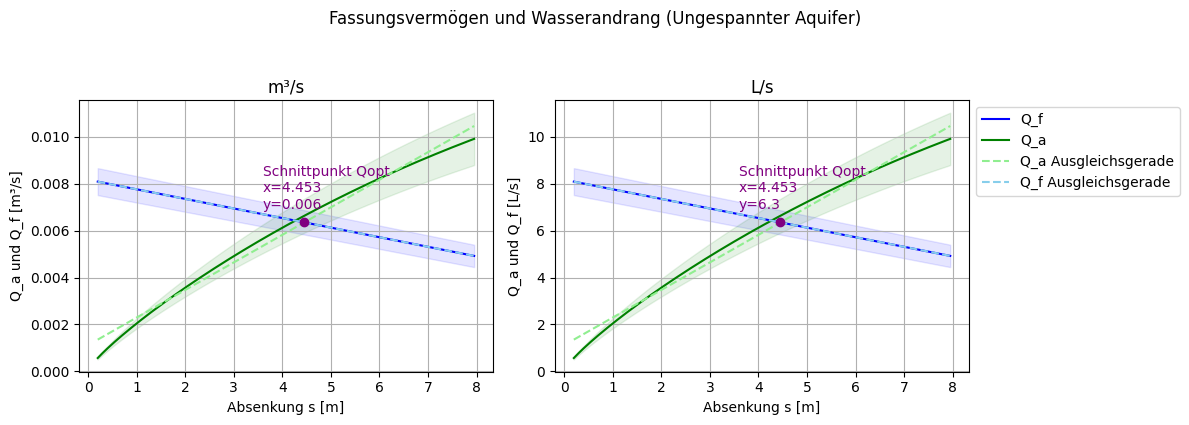

Optimaler Betriebspunkt im ungespannten Aquifer bei: s = 4.453 m und Q = 0.0063 m3/s (6.3 L/s)


In [101]:
x_ug = df_ungespannt["s [m]"].values.reshape(-1, 1)
y_ug = df_ungespannt["Q_a [m3/s]"]
y_ug2 = df_ungespannt["Q_f [m3/s]"]

regressor = LinearRegression()
regressor2 = LinearRegression()

regressor.fit(x_ug, y_ug)
regressor2.fit(x_ug, y_ug2)

y_pred = regressor.predict(x_ug)
y_pred2 = regressor2.predict(x_ug)

m1 = regressor.coef_[0]
b1 = regressor.intercept_

m2 = regressor2.coef_[0]
b2 = regressor2.intercept_

x_ug_schnitt = (b2 - b1) / (m1 - m2)
y_ug_schnitt = m1 * x_ug_schnitt + b1

# Data
x = np.array(df_ungespannt['s [m]'])
y_f = np.array(df_ungespannt['Q_f [m3/s]'])
dy_f = np.array(df_ungespannt['ΔQ_f [m3/s]'])
y_a = np.array(df_ungespannt['Q_a [m3/s]'])
dy_a = np.array(df_ungespannt['ΔQ_a [m3/s]'])

factor = 1000  # m3/s → L/s

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Left: m3/s
axes[0].fill_between(x, y_f - dy_f, y_f + dy_f, color='blue', alpha=0.1)
axes[0].plot(x, y_f, color='blue', label='Q_f')
axes[0].fill_between(x, y_a - dy_a, y_a + dy_a, color='green', alpha=0.1)
axes[0].plot(x, y_a, color='green', label='Q_a')


axes[0].plot(x_ug, y_pred, color="lightgreen", linestyle="--", label="Q_a Ausgleichsgerade")  # für Qa
axes[0].plot(x_ug, y_pred2, color="skyblue", linestyle="--", label="Q_f Ausgleichsgerade") # für Qf

axes[0].scatter(x_ug_schnitt, y_ug_schnitt, color="purple", zorder=5)
axes[0].annotate(
    f"Schnittpunkt Qopt\nx={x_ug_schnitt:.3f}\ny={y_ug_schnitt:.3f}",
    (x_ug_schnitt, y_ug_schnitt),
    textcoords="offset points",
    xytext=(-30, 10),
    color="purple"
)

axes[0].set_title("m³/s")
axes[0].set_xlabel("Absenkung s [m]")
axes[0].set_ylabel("Q_a und Q_f [m³/s]")
axes[0].grid()

# Right L/s
axes[1].fill_between(x, (y_f - dy_f)*factor, (y_f + dy_f)*factor, color='blue', alpha=0.1)
axes[1].plot(x, y_f*factor, color='blue', label='Q_f')
axes[1].fill_between(x, (y_a - dy_a)*factor, (y_a + dy_a)*factor, color='green', alpha=0.1)
axes[1].plot(x, y_a*factor, color='green', label='Q_a')

# "Ausgleichsgeraden" für Schnittpunkt
axes[1].plot(x_ug, y_pred*factor, color="lightgreen", linestyle="--", label="Q_a Ausgleichsgerade") # für Qa
axes[1].plot(x_ug, y_pred2*factor, color="skyblue", linestyle="--", label="Q_f Ausgleichsgerade") # für Qf

# Schnittpunkt markieren
axes[1].scatter(x_ug_schnitt, y_ug_schnitt*factor, color="purple", zorder=5)
axes[1].annotate(
    f"Schnittpunkt Qopt\nx={x_ug_schnitt:.3f}\ny={(y_ug_schnitt*factor):.1f}",
    (x_ug_schnitt, y_ug_schnitt*factor),
    textcoords="offset points",
    xytext=(-30, 10),
    color="purple")

axes[1].set_title("L/s")
axes[1].set_xlabel("Absenkung s [m]")
axes[1].set_ylabel("Q_a und Q_f [L/s]")
axes[1].grid()

plt.suptitle('Fassungsvermögen und Wasserandrang (Ungespannter Aquifer)', y=1.05)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

print("Optimaler Betriebspunkt im ungespannten Aquifer bei: "
      f"s = {x_ug_schnitt:.3f} m und "
      f"Q = {y_ug_schnitt:.4f} m3/s "
      f"({y_ug_schnitt*factor:.1f} L/s)")


In [102]:
# TEST Monte Carlo
def find_intersection(kf_val, hF_val):
    s_vals = np.linspace(0.01, hF_val*0.9, 500) #feines Raster für s-Werte von 0.01 m bis 90% der Filterlänge

    Qa_vals = []
    Qf_vals = []

    for s in s_vals:
        Qa, _ = calc_delta_Qa(s, kf_val, hF_val, calc_r_e)
        Qf, _ = calc_Qf_and_error(s, kf_val, hF_val, hydro_r_bl_value)
        Qa_vals.append(Qa)
        Qf_vals.append(Qf)

    diff = np.array(Qa_vals) - np.array(Qf_vals) # Differenz zwischen Qa und Qf für jedes s
    idx = np.argmin(np.abs(diff)) # Index des minimalen Absolutwerts der Differenz

    return Qa_vals[idx]

In [103]:
N = 300 # Anzahl der Monte-Carlo-Simulationen 
Qopt_samples = []

# Lognormal-Parameter bestimmen
sigma_ln = delta_kf / hydro_kf_value  # Näherung für kleine Streuung
mu_ln = np.log(hydro_kf_value)

for _ in range(N):

    # kf lognormal ziehen (immer > 0)
    kf_rand = np.random.lognormal(mean=mu_ln, sigma=sigma_ln)

    # hF normal ziehen
    hF_rand = np.random.normal(hydro_b_value, delta_hF)

    # Sicherheitscheck
    if hF_rand <= 0:
        continue

    Qopt_samples.append(find_intersection(kf_rand, hF_rand))


In [168]:
Qopt_mean = np.mean(Qopt_samples) # Mittelwert
Qopt_std = np.std(Qopt_samples) # Standardabweichung

Qopt_p5 = np.percentile(Qopt_samples, 5)
Qopt_p95 = np.percentile(Qopt_samples, 95)

print(f"Qopt = {Qopt_mean:.5f} m³/s bzw. {Qopt_mean*factor:.1f} L/s")
print(f"Standardabweichung = ±{Qopt_std:.5f} m³/s (1σ) bzw. ±{Qopt_std*factor:.1f} L/s")
print(f"90%-Intervall: {Qopt_p5:.5f} – {Qopt_p95:.5f} m³/s bzw. {Qopt_p5*factor:.1f} – {Qopt_p95*factor:.1f} L/s")


Qopt = 0.00644 m³/s bzw. 6.4 L/s
Standardabweichung = ±0.00057 m³/s (1σ) bzw. ±0.6 L/s
90%-Intervall: 0.00557 – 0.00746 m³/s bzw. 5.6 – 7.5 L/s


# 3. Brunnendimensionierung

## 3.1. Hydraulisches Abstandkriterium

In [105]:
def calc_d_hyd_min(Q_vol, k_f, b, i):
    """Berechnung des minimalen hydraulischen Abstandes d_hyd_min [m] zwischen Förder- und Injektionsbrunnen.

    Args:
        Q_vol (float): Fördervolumenstrom [m³/s]
        k_f (float): hydraulischer Durchlässigkeitsbeiwert [m/s]
        b (float): Aquifermächtigkeit [m]
        i (float): lokaler hydraulischer Gradient [–]
    """
    d_hyd_min = (2*Q_vol)/(np.pi*k_f*b*i)
    return d_hyd_min

In [106]:
d_hyd_min_value = calc_d_hyd_min(Q_vol=Q_vol_h_value[0], k_f=hydro_kf_value, b=hydro_b_value, i=hydro_i_value)
print(f'Der minimale hydraulische Abstand beträgt: {d_hyd_min_value:.2f} m')

Der minimale hydraulische Abstand beträgt: 5.31 m


In [107]:
# Fehlerberchnung Test d_hyd
# Gegeben
kf = hydro_kf_value # in m/s
delta_kf = (10*kf-(kf/10))/(2)  # Fehler kf
b = hydro_b_value # in m
delta_b = 1      # Fehler b
i = hydro_i_value
Q_vol = Q_vol_h_value[0]     

# d_hyd berechnen
d_hyd = (2*Q_vol)/(np.pi*kf*b*i)

# Ableitungen
dQ_dkf = (-2*Q_vol)/(math.pi*b*i*kf**2)
dQ_db = (-2*Q_vol)/(math.pi*kf*i*b**2)

# Fehlerfortpflanzung
delta_d_hyd = math.sqrt((dQ_dkf * delta_kf)**2 + (dQ_db * delta_b)**2)

print(f"d_hyd = {d_hyd:.3f} m")
print(f"Fehler Δd_hyd = {delta_d_hyd:.3f} m")

d_hyd = 5.305 m
Fehler Δd_hyd = 26.262 m


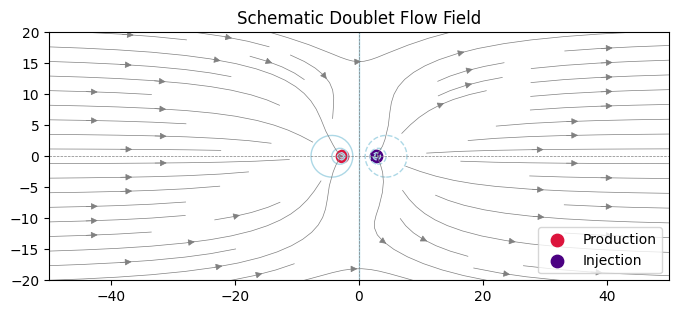

In [108]:
x_grid = np.linspace(-50, 50, 200)
y_grid = np.linspace(-20, 20, 150)
X, Y = np.meshgrid(x_grid, y_grid)

k_f = hydro_kf_value # m/s
b = hydro_b_value # m
T = k_f * b

i = hydro_i_value
q = k_f * i       # Darcy velocity

Q_prod = -Q_vol_h_value[0]   # m³/s
Q_inj  =  Q_vol_h_value[0]  # m³/s 


# Well positions
distance = d_hyd_min_value * 1.05  # Abstand zwischen Förder- und Injektionsbrunnen in m
x_prod, y_prod = -distance/2, 0
x_inj,  y_inj  =  distance/2, 0

# Distance to wells
r_prod = np.sqrt((X - x_prod)**2 + (Y - y_prod)**2) + 1e-6
r_inj  = np.sqrt((X - x_inj)**2  + (Y - y_inj)**2)  + 1e-6

#Potential
T = k_f * b

phi = q * X + (Q_prod /(2*np.pi*T)) * np.log(r_prod) + (Q_inj  /(2*np.pi*T)) * np.log(r_inj)


# Velocity components
u = q + (Q_prod/(2*np.pi)) * (X - x_prod)/r_prod**2 + (Q_inj /(2*np.pi)) * (X - x_inj )/r_inj**2

v = (Q_prod/(2*np.pi)) * (Y - y_prod)/r_prod**2 + (Q_inj /(2*np.pi)) * (Y - y_inj )/r_inj**2

# Plot
plt.figure(figsize=(8,4))

# Equipotential lines
plt.contour(X, Y, phi, levels=10, colors='lightblue', linewidths=1)

# Streamlines
plt.streamplot(X, Y, u, v, density=0.6, color='grey', linewidth=0.5, arrowsize=1)

# Wells
plt.scatter(x_prod, y_prod, color='crimson', s=80, label='Production')
plt.scatter(x_inj, y_inj, color='indigo', s=80, label='Injection')

plt.axhline(0, linestyle='--', color='gray', linewidth=0.5)
plt.axvline(0, linestyle='--', color='gray', linewidth=0.5)

plt.title("Schematic Doublet Flow Field")
plt.gca().set_aspect('equal')
plt.legend()
plt.show()


In [109]:
# Test Berechnung lokaler hydraulischer Gradient i_l
s_br = 0.3 # Absenkung am Brunnenschacht in m --> abschätzen mit max. GW-Fördermenge in Q-s Diagramm
delta_h = ((hydro_b_value + s_br)-(hydro_b_value - s_br)) # Differenz der potentiellen Höhen von Förder- und Injektionsbrunnen in m

i_l = (delta_h)/d_hyd_min_value
print(f"Der lokale hydraulische Gradient beträgt: {i_l:.4f}")

Der lokale hydraulische Gradient beträgt: 0.1131


## 3.2. Thermischer Durchbruch

In [110]:
def calc_t_th(vWK_aq, vWK_gw, k_f, b, i, d_hyd, Q_vol):
    """Berechnung der theoretischen Zeit t_th [s] bis zum thermischen Kurzschluss zwischen Förder- und Injektionsbrunnen.

    Args:
        vWK_aq (float): Volumetrische Wärmekapazität des Aquifers [J/m³K]
        vWK_gw (float): Volumetrische Wärmekapazität des Grundwassers [J/m³K]
        k_f (float): hydraulischer Durchlässigkeitsbeiwert [m/s]
        b (float): Aquifermächtigkeit [m]
        i (float): hydraulischer Gradient [–]
        d_hyd (float): hydraulischer Abstand zwischen Förder- und Injektionsbrunnen [m]
        Q_vol (float): GW-Fördervolumen [m³/s]
    """
    d_hyd_safe = d_hyd * 1.05
    i_down = -1 * i # da I-Br. unterstromig F-Br. und GW somit "rückwärts" fließt ist i<0 definiert
    alpha = Q_vol/(2*np.pi*k_f*b*i_down*d_hyd_safe) 
    eps = 1e-10

    if alpha > -0.25:
        print("Warnung: Alpha außerhalb des gültigen Bereichs:", alpha)
        return None
    # elif abs(alpha + 0.25) < eps:
    #     # Grenzfall
    #     factor = 1 - np.pi / 2
    # else:
    #     root = np.sqrt(-1 - 4*alpha)
    #     factor = 1 + (4*alpha / root) * np.arctan(1 / root)

    root = np.sqrt(-1 - 4*alpha)
    factor = 1 + (4*alpha / root) * np.arctan(1 / root)
    t_th = ((vWK_aq * d_hyd_safe) / (vWK_gw * k_f * i_down) * factor) / (3600*24) # in Tagen

    return t_th


In [111]:
# t = calc_t_th(vWK_aq=2.5*10**6, vWK_gw=4.18*10**6, k_f=hydro_kf_value, b=hydro_b_value, i=i_l, d_hyd=d_hyd_min_value, Q_vol=Q_vol_h_value[0])
# print(f'Die theoretische Zeit bis zum thermischen Kurzschluss beträgt: {t:.2f} Tage', f"({t/365:.2f} Jahre)")

## 3.3. Thermische Ausbreitung

In [118]:
# Querdispersivität Auswahl
querdisp_df = pd.DataFrame({
    "Querdispersivität": [0.1, 0.18, 0.34, 0.62, 1],
    "Bereich x0": ["< 50 m", "< 100 m", "<250 m", "< 500 m", "> 500 m"]}) #für die 1 K Isotherme
querdisp_df

,Querdispersivität,Bereich x0
0,0.10,< 50 m
1,0.18,< 100 m
2,0.34,<250 m
3,0.62,< 500 m
4,1.00,> 500 m


In [155]:
# x0 Berechnung
def calc_x0(Q_inf, b, kf, i, alpha_T, deltaT_inf, deltaT_iso):
    """Berechnung der Entfernung x0 [m] zwischen Förder- und Injektionsbrunnen, bei der die Temperaturdifferenz zwischen Infiltrat und Grundwasser auf die gesuchte Isotherme deltaT_iso [K] abgesunken ist.

    Args:
        Q_inf (float): Infiltrationsrate [m³/s]
        b (float): Aquifermächtigkeit [m]
        kf (float): hydraulischer Durchlässigkeitsbeiwert [m/s]
        i (float): hydraulischer Gradient [–]
        alpha_T (float): Querdispersivität [-]
        deltaT_inf (float): Temperaturdifferenz zwischen Infiltrat und Grundwasser [K]
        deltaT_iso (float): Gesuchte Isotherme [K]
    """
    x0 = (1/(4*np.pi*alpha_T)) * ((Q_inf*deltaT_inf)/(b*kf*i*deltaT_iso))**2
    return x0

# x0 Berechnung mit Fehler
def calc_x0_with_error(Q_inf, b, kf, i, alpha_T, deltaT_inf, deltaT_iso, sigma_b, sigma_kf, sigma_i):
    """Fehlerberechnung für x0 unter Berücksichtigung der Fehler von b, kf und i.

    Args:
        Q_inf (float): Infiltrationsrate [m³/s]
        b (float): Aquifermächtigkeit [m]
        kf (float): hydraulischer Durchlässigkeitsbeiwert [m/s]
        i (float): hydraulischer Gradient [–]
        alpha_T (float): Querdispersivität [-]
        deltaT_inf (float): Temperaturdifferenz zwischen Infiltrat und Grundwasser [K]
        deltaT_iso (float): Gesuchte Isotherme [K]
        sigma_b (float): Fehler der Aquifermächtigkeit [m]
        sigma_kf (float): Fehler des hydraulischen Durchlässigkeitsbeiwerts [m/s]
        sigma_i (float): Fehler des hydraulischen Gradienten [–]

    Returns:
        tuple: (x0, sigma_x0) - x0 und dessen Fehler
    """
    # Filtergeschwindigkeit
    v_f = kf * i
    # Fehler von v_f
    sigma_vf_rel = np.sqrt((sigma_kf/kf)**2 + (sigma_i/i)**2)
    # x0 berechnen
    x0 = x0 = (1/(4*np.pi*alpha_T)) * ((Q_inf*deltaT_inf)/(b*v_f*deltaT_iso))**2
    # relative Fehler
    rel_error = np.sqrt((2*sigma_b/b)**2 + (2*sigma_vf_rel)**2)
    sigma_x0 = x0 * rel_error
    
    return x0, sigma_x0

# y Berechnung
def calc_y(x, alpha_T, Q_inf, deltaT_inf, deltaT_iso, kf, i, b):
    """
    Berechnet die halbe seitliche Ausdehnung y [m] der Isotherme in Bezug auf die Stromlinie für Punkte x < x0
    Args:
        x (float): stromabwärtige Entfernung vom Injektionsbrunnen [m]
        alpha_T (float): Querdispersivität [m]
        Q_inf (float): Infiltrationsrate [m3/s]
        deltaT_inf (float): Temperaturdifferenz zwischen Einleittemperatur und ungestörter Grundwassertemperaur [K]
        deltaT_iso (float): gesuchte Isotherme [K]
        kf (float): hydraulischer Durchlässigkeitsbeiwert [m/s]
        i (float): hydraulischer Gradient [–]
        b (float): Aquifermächtigkeit [m]
    """
    y = np.sqrt(4 * alpha_T * x * np.log((Q_inf*deltaT_inf)/(b*kf*i*deltaT_iso*np.sqrt(4*np.pi*alpha_T*x))))
    return y

In [156]:
# Q_inf = Q_vol_h_value[0] # in m3/s
# b = hydro_b_value # in m
# kf = hydro_kf_value # in m/s
# i = hydro_i_value 
# alpha_T = 0.18 # je nach x0 anpassen
# deltaT_inf = T_slider.value
# deltaT_iso = 3

# # Unsicherheiten
# sigma_b = 1
# sigma_kf = 0.0001
# sigma_i = 0.001

# x0, sigma_x0 = calc_x0_with_error(Q_inf, b, kf, i, alpha_T, deltaT_inf, deltaT_iso, sigma_b, sigma_kf, sigma_i)
# print(f"x0 = {x0:.2f} ± {sigma_x0:.2f} m")

# y = calc_y(x0, x0*0.5, alpha_T, Q_inf, deltaT_inf, deltaT_iso, kf*i, b)
# print(f"y = {y:.2f} m für x = {x0*0.5:.2f} m")

In [180]:
deltaT_iso_values = [3, 2, 1]  # K
alpha_T_value = 0.34 # je nach x0 anpassen
x0_results = {}

for deltaT_iso in deltaT_iso_values:
    
    x0 = calc_x0(
        Q_inf=Q_vol_h_value[0],
        b=hydro_b_value,
        kf=hydro_kf_value,
        i=hydro_i_value,
        alpha_T=alpha_T_value, # je nach x0 anpassen
        deltaT_inf=3,
        deltaT_iso=deltaT_iso)
    

    x0_results[deltaT_iso] = x0   # store value
    x_value = x0/2

    y = calc_y(
        x=x_value,
        alpha_T=alpha_T_value, # je nach x0 anpassen
        Q_inf=Q_vol_h_value[0],
        deltaT_inf=3,
        deltaT_iso=deltaT_iso,
        kf=hydro_kf_value,
        i=hydro_i_value,
        b=hydro_b_value)

    print(
        f"ΔT_iso = {deltaT_iso} K\n"
        f"  → Abstand x0 ca.: {x0:.0f} m\n"
        f"  → Halbe Ausdehnung y bei x={x_value:.0f} m ca. : {y:.0f} m\n")


ΔT_iso = 3 K
  → Abstand x0 ca.: 16 m
  → Halbe Ausdehnung y bei x=8 m ca. : 2 m

ΔT_iso = 2 K
  → Abstand x0 ca.: 37 m
  → Halbe Ausdehnung y bei x=18 m ca. : 3 m

ΔT_iso = 1 K
  → Abstand x0 ca.: 146 m
  → Halbe Ausdehnung y bei x=73 m ca. : 6 m



C:\Users\helen\AppData\Local\Temp\ipykernel_26652\3857813843.py:62: RuntimeWarning: invalid value encountered in sqrt
  y = np.sqrt(4 * alpha_T * x * np.log((Q_inf*deltaT_inf)/(b*kf*i*deltaT_iso*np.sqrt(4*np.pi*alpha_T*x))))


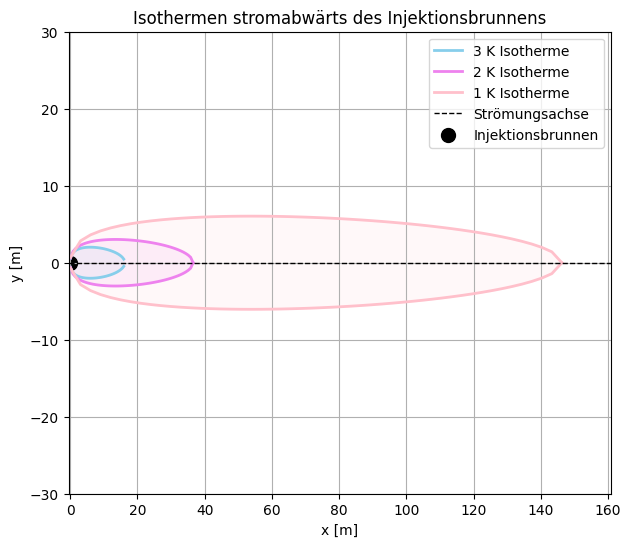

In [182]:
deltaT_iso_values = [3, 2, 1]   # gewünschte Isothermen
colors_isothermen = {1: "pink", 2: "violet", 3: "skyblue"}
x_value_min = 0.1

plt.figure(figsize=(7, 6))

for deltaT_iso in deltaT_iso_values:

    # x0 berechnen
    x0 = calc_x0(Q_inf=Q_vol_h_value[0], b=hydro_b_value, kf=hydro_kf_value, i=hydro_i_value, alpha_T=alpha_T_value, deltaT_inf=3, deltaT_iso=deltaT_iso)

    # x-Werte abhängig vom jeweiligen x0
    x_array = np.linspace(x_value_min, x0, 50)

    # y-Werte berechnen
    y_array = np.array([calc_y(x=x, alpha_T=alpha_T_value, Q_inf=Q_vol_h_value[0], deltaT_inf=3, deltaT_iso=deltaT_iso, kf=hydro_kf_value, i=hydro_i_value, b=hydro_b_value) for x in x_array])

    # Linien plotten
    plt.plot(x_array,  y_array, linewidth=2, color=colors_isothermen[deltaT_iso], label=f"{deltaT_iso} K Isotherme")
    plt.plot(x_array, -y_array, linewidth=2, color=colors_isothermen[deltaT_iso])

    # Bereich füllen
    plt.fill_between(x_array, -y_array, y_array, alpha=0.1, color=colors_isothermen[deltaT_iso])

# Strömungsachse und Injektionsbrunnen
plt.axhline(0, linestyle='dashed', color='black', linewidth=1, label='Strömungsachse')
plt.scatter(0, 0, color='black', s=100, label='Injektionsbrunnen')

plt.title("Isothermen stromabwärts des Injektionsbrunnens")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.grid(True)
x_limit = max([calc_x0(Q_inf=Q_vol_h_value[0], b=hydro_b_value, kf=hydro_kf_value, i=hydro_i_value, alpha_T=alpha_T_value, deltaT_inf=3, deltaT_iso=iso) for iso in deltaT_iso_values]) * 1.1
plt.xlim(-0.5, x_limit)
plt.ylim(-30, 30)
plt.legend()
plt.show()

## 3.3. Finale Auswertung

In [174]:
print("Zusammenfassung der Ergebnisse:")
print("-----------------------------------------------------------------------")
a1 = "Heizen und Warmwasser" if P_df["Kühlleistung [W]"].min() == 0 else "Heizen, Kühlen und Warmwasser"
print("Die Anlage wird zum", a1, "Betrieb verwendet.")
print("Die mittlere Jahresluft- und Grundwassertemperatur beträgt:", round(GW_temp, 2), "°C am gewählten Standort:", Ort)
if P_df["Kühlleistung [W]"].min() != 0:
    print("Das gewählte Gebäude (", dropdown.value,") hat einen Jahreswärmebedarf von", Jahreswärmebedarf_slider.value, "kWh/a und einen Jahreskühlbedarf von", Jahreskühlbedarf_slider.value, "kWh/a")
else:
    print("Das gewählte Gebäude (", dropdown.value,") hat einen Jahreswärmebedarf von", Jahreswärmebedarf_slider.value, "kWh/a")
print("Die Anlage wird ausgelegt auf eine maximal erforderliche Grundwasserentzugsleistung von:", round(Q_vol_h_value[0]*3600, 2), "m³/h im Heizbetrieb.")
print("Die Temperaturdifferenz zwischen Einleittemperatur und ungestörter Grundwassertemperaur beträgt:", T_slider.value, "K.")
print("-----------------------------------------------------------------------")
Qopt_mean_m3h = Qopt_mean * 3600
print("Zur Vermeidung einer hydrogeologischen Überanspruchung des Aquifers sollte das Grundwasser-Fördervolumen nicht über dem optimalen Betriebspunkt von", round(Qopt_mean_m3h, 2), "m³/h liegen.")
if Q_vol_h_value[1] > Qopt_mean_m3h:
    print("Mit einem Grundwasser-Fördervolumen von", round(Q_vol_h_value[1], 2), "m³/h besteht die Gefahr einer hydrogeologischen Überanspruchung des Aquifers.")
else:
    print("Das Grundwasser-Fördervolumen von", round(Q_vol_h_value[1], 2), "m³/h liegt unter dem optimalen Betriebspunkt, eine hydrogeologische Überanspruchung des Aquifers ist unwahrscheinlich.")
print("-----------------------------------------------------------------------")
print("Der minimale hydraulische Abstand zwischen Förder- und Injektionsbrunnen beträgt:", round(d_hyd_min_value, 2), "m (±", round(delta_d_hyd, 2), "m).")
# print("Die theoretische Zeit bis zum thermischen Kurzschluss beträgt:", round(t, 2), "Tage (", round(t/365, 2), "Jahre).")
deltaT = deltaT_iso_values[0]
x0_value = x0_results[deltaT]

print(f"Die stromabwärtige Entfernung vom Injektionsbrunnen zur {deltaT} K-Isotherme beträgt: {x0_value:.0f} m. Die thermische Ausbreitung stromabwärts könnte Auswirkungen auf benachbarte Brunnenanlagen haben.")

Zusammenfassung der Ergebnisse:
-----------------------------------------------------------------------
Die Anlage wird zum Heizen, Kühlen und Warmwasser Betrieb verwendet.
Die mittlere Jahresluft- und Grundwassertemperatur beträgt: 10.06 °C am gewählten Standort: Aachen
Das gewählte Gebäude ( Einfamilienhaus ) hat einen Jahreswärmebedarf von 15000 kWh/a und einen Jahreskühlbedarf von 600 kWh/a
Die Anlage wird ausgelegt auf eine maximal erforderliche Grundwasserentzugsleistung von: 1.8 m³/h im Heizbetrieb.
Die Temperaturdifferenz zwischen Einleittemperatur und ungestörter Grundwassertemperaur beträgt: 3 K.
-----------------------------------------------------------------------
Zur Vermeidung einer hydrogeologischen Überanspruchung des Aquifers sollte das Grundwasser-Fördervolumen nicht über dem optimalen Betriebspunkt von 23.19 m³/h liegen.
Das Grundwasser-Fördervolumen von 1.79 m³/h liegt unter dem optimalen Betriebspunkt, eine hydrogeologische Überanspruchung des Aquifers ist unwahrs